In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
amir_deals = pd.read_csv('amir_deals.csv')
amir_deals.head()

,Unnamed: 0,product,client,status,amount,num_users
0,1,Product F,Current,Won,7389.52,19
1,2,Product C,New,Won,4493.01,43
2,3,Product B,New,Won,5738.09,87
3,4,Product I,Current,Won,2591.24,83
4,5,Product E,Current,Won,6622.97,17


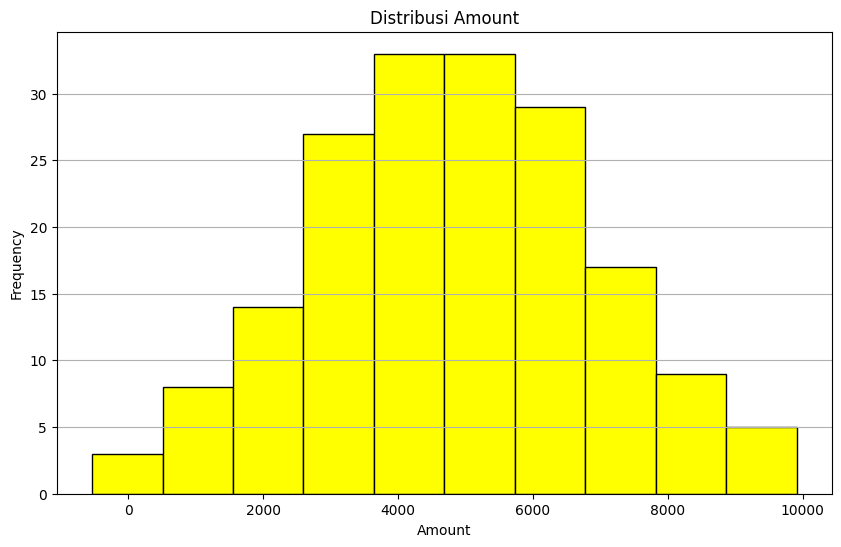

In [96]:
# Membuat histogram untuk kolom amount dengan 10 bins
plt.figure(figsize=(10, 6))
plt.hist(amir_deals['amount'], bins=10, color='yellow', edgecolor='black')
plt.title("Distribusi Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()

In [97]:
from scipy.stats import norm

# Menghitung rata-rata dan standar deviasi dari kolom 'amount'
mean_amount = amir_deals['amount'].mean()
sd_amount = amir_deals['amount'].std()

# Menghitung probabilitas
prob_less_7500 = norm.cdf(7500, loc=mean_amount, scale=sd_amount)
prob_greater_1000 = 1 - norm.cdf(1000, loc=mean_amount, scale=sd_amount)
prob_between_3000_and_7000 = norm.cdf(7000, loc=mean_amount, scale=sd_amount) - norm.cdf(3000, loc=mean_amount, scale=sd_amount)

# Menghitung kuantil untuk 25%
amount_25_percentile = norm.ppf(0.25, loc=mean_amount, scale=sd_amount)

# Menampilkan hasil
print(f"Probability of deal < 7500: {prob_less_7500:.4f}")
print(f"Probability of deal > 1000: {prob_greater_1000:.4f}")
print(f"Probability of deal between 3000 and 7000: {prob_between_3000_and_7000:.4f}")
print(f"Amount that 25% of deals will be less than: {amount_25_percentile:.2f}")

Probability of deal < 7500: 0.9042
Probability of deal > 1000: 0.9680
Probability of deal between 3000 and 7000: 0.6668
Amount that 25% of deals will be less than: 3423.78


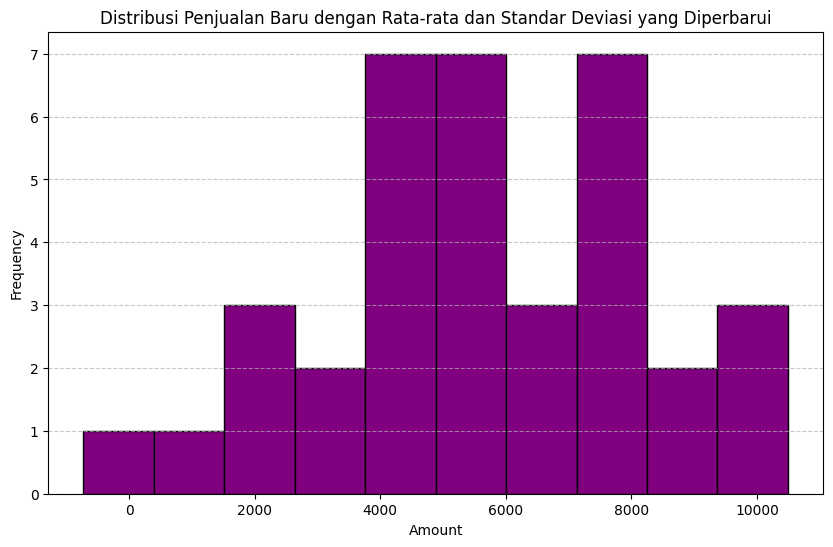

In [98]:
# Membaca data dari amir_deals.csv
amir_deals = pd.read_csv('amir_deals.csv')

# Menghitung rata-rata dan standar deviasi dari kolom 'amount'
mean_amount = amir_deals['amount'].mean()
sd_amount = amir_deals['amount'].std()

# Menghitung rata-rata dan standar deviasi baru
new_mean = mean_amount * 1.2  
new_sd = sd_amount * 1.3      

# Mensimulasikan 36 penjualan baru menggunakan distribusi normal
new_sales = norm.rvs(loc=new_mean, scale=new_sd, size=36)

# Membuat histogram dari penjualan baru
plt.figure(figsize=(10, 6))
plt.hist(new_sales, bins=10, color='purple', edgecolor='black')
plt.title("Distribusi Penjualan Baru dengan Rata-rata dan Standar Deviasi yang Diperbarui")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

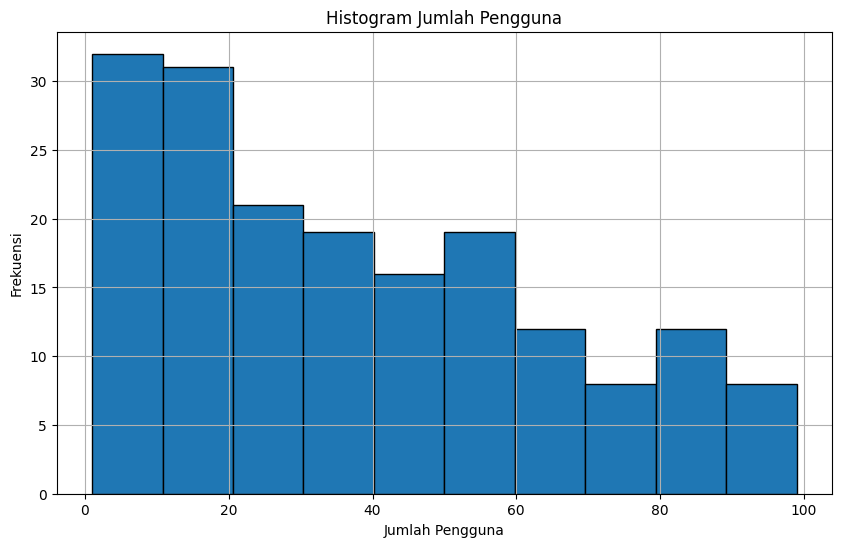

In [101]:
# Buat histogram dari kolom 'num_users'
plt.figure(figsize=(10, 6))
amir_deals['num_users'].hist (edgecolor='black')

# Beri judul dan label sumbu
plt.title('Histogram Jumlah Pengguna')
plt.xlabel('Jumlah Pengguna')
plt.ylabel('Frekuensi')

# Tampilkan plot
plt.show()

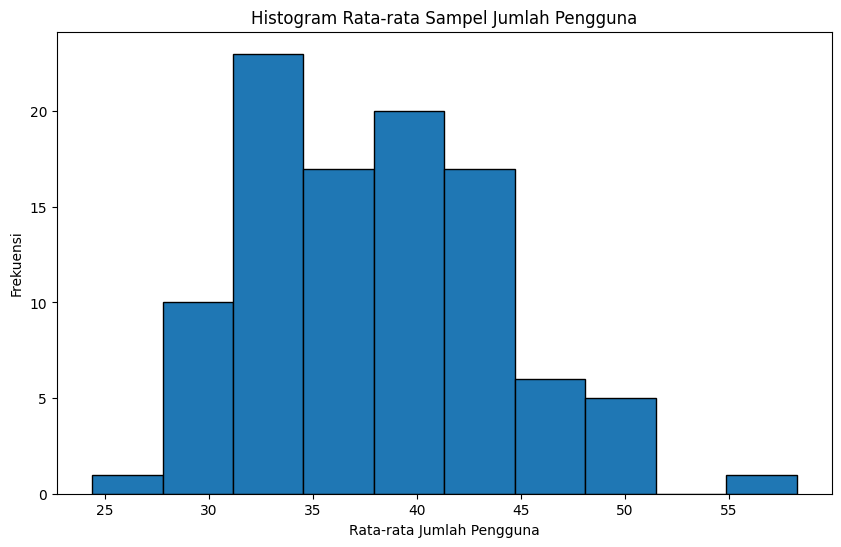

In [112]:
# Baca data dari file CSV
amir_deals = pd.read_csv('amir_deals.csv')

# Atur seed untuk reproduksibilitas
np.random.seed(104)

# Buat 100 sampel acak dari 'num_users' dengan ukuran sampel 15
sample_sizes = [20] * 100
sample_data = [amir_deals['num_users'].sample(size, replace=True) for size in sample_sizes]

# Hitung rata-rata dari setiap sampel
sample_means = [np.mean(sample) for sample in sample_data]

# Buat histogram dari rata-rata sampel
plt.figure(figsize=(10, 6))
plt.hist(sample_means, edgecolor='black')
plt.title('Histogram Rata-rata Sampel Jumlah Pengguna')
plt.xlabel('Rata-rata Jumlah Pengguna')
plt.ylabel('Frekuensi')
plt.show()

In [120]:
all_deals = pd.read_csv('all_deals.csv', index_col=0)
all_deals.head()

,product,num_users
Unnamed: 0,,
1,3544,19
2,5073,43
3,6149,87
4,7863,83
5,14,17


In [123]:
import pandas as pd
import numpy as np

# Baca data dari file CSV
amir_deals = pd.read_csv('amir_deals.csv')
all_deals = pd.read_csv('all_deals.csv')  

# Set seed untuk reproduksibilitas
np.random.seed(321)

# Ambil 30 rata-rata sampel dengan ukuran 20 secara efisien
sample_means = [
    all_deals['num_users'].sample(20, replace=True).mean() for _ in range(30)
]

# Print rata-rata dari sample_means
print(f"Mean of sample means: {np.mean(sample_means):.2f}")

# Print rata-rata dari num_users dalam amir_deals
print(f"Mean of num_users in amir_deals: {amir_deals['num_users'].mean():.2f}")

Mean of sample means: 38.31
Mean of num_users in amir_deals: 37.65


In [124]:
# Import library yang diperlukan
from scipy.stats import poisson

# Fungsi untuk menghitung probabilitas Poisson
def calculate_poisson_probabilities():
    # Probability of 5 responses with lambda = 4
    prob_5 = poisson.pmf(5, 4)
    
    # Probability of 5 responses with lambda = 5.5
    prob_coworker = poisson.pmf(5, 5.5)
    
    # Probability of 2 or fewer responses with lambda = 4
    prob_2_or_less = poisson.cdf(2, 4)
    
    # Probability of more than 10 responses with lambda = 4
    prob_over_10 = 1 - poisson.cdf(10, 4)
    
    return {
        "prob_5": prob_5,
        "prob_coworker": prob_coworker,
        "prob_2_or_less": prob_2_or_less,
        "prob_over_10": prob_over_10
    }

# Hitung probabilitas
probabilities = calculate_poisson_probabilities()

# Print hasil
for key, value in probabilities.items():
    print(f"{key}: {value:.4f}")

prob_5: 0.1563
prob_coworker: 0.1714
prob_2_or_less: 0.2381
prob_over_10: 0.0028


In [126]:
from scipy.stats import expon

def calculate_exponential_probabilities(rate):
    # Probability response takes < 1 hour
    prob_less_than_1 = expon.cdf(1, rate)
    
    # Probability response takes > 4 hours
    prob_greater_than_4 = 1 - expon.cdf(4, rate)
    
    # Probability response takes between 3 and 4 hours
    prob_between_3_and_4 = expon.cdf(4, rate) - expon.cdf(3, rate)
    
    return {
        "prob_less_than_1": prob_less_than_1,
        "prob_greater_than_4": prob_greater_than_4,
        "prob_between_3_and_4": prob_between_3_and_4
    }

# Set rate (lambda)
rate = 0.4

# Calculate probabilities
probabilities = calculate_exponential_probabilities(rate)

# Print results
for key, value in probabilities.items():
    print(f"{key}: {value:.4f}")

prob_less_than_1: 0.4512
prob_greater_than_4: 0.0273
prob_between_3_and_4: 0.0469
